In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

In [ ]:
# Get data from local source

df = pd.read_csv("iris.data",header=None)
X = df.iloc[:, :-1].values
y_labels = df.iloc[:, -1]
y, target_names = pd.factorize(y_labels)

In [ ]:
from sklearn.preprocessing import StandardScaler
from numpy.linalg import eig
# Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Calculate the covariance matrix
cov_mat=np.cov(X_std.T)


# Calculate the eigenvectors and eigenvalues
eigenvalues, eigenvectors = eig(cov_mat)

# Choose components and form a feature vector
eigen_pairs = [(np.abs(eigenvalues[i]), eigenvectors[:, i]) for i in range(len(eigenvalues))]
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

k = 2
W = np.hstack([eigen_pairs[i][1][:, np.newaxis] for i in range(k)])

# Derive the new data set
X_pca_scratch = X_std.dot(W)

/tmp/ipython-input-3286848953.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))


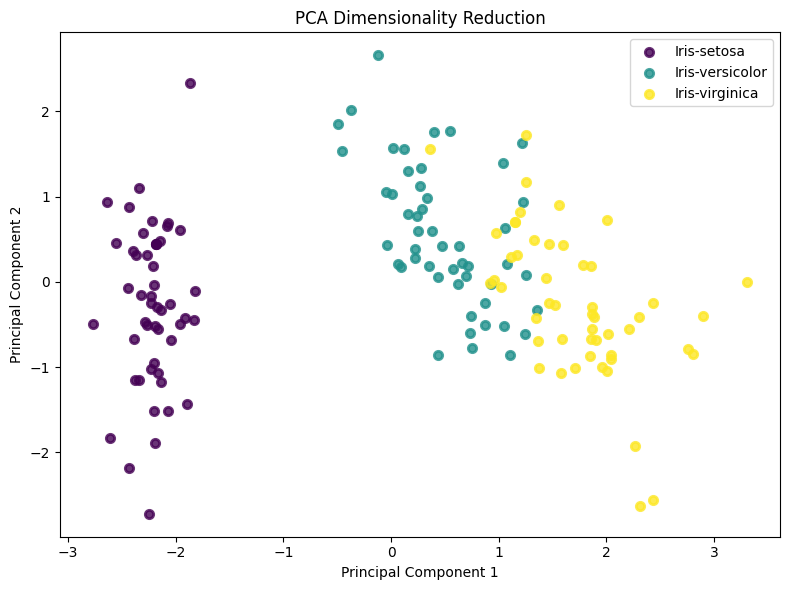

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 6))

# Use a colormap to handle any number of classes
unique_labels = np.unique(y)
colors = plt.cm.get_cmap('viridis', len(unique_labels))
lw = 2

# Plot for "From Scratch" PCA
for i, target_name in zip(unique_labels, target_names):
    ax.scatter(X_pca_scratch[y == i, 0], X_pca_scratch[y == i, 1],
                color=colors(i), alpha=.8, lw=lw, label=target_name)
ax.set_title('PCA Dimensionality Reduction')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(loc='best', shadow=False, scatterpoints=1)

plt.tight_layout()
plt.show()

In [ ]:
#SVD
df = pd.read_csv("iris.data",header=None)
X = df.iloc[:, :-1].values
y_labels = df.iloc[:, -1]
y, target_names = pd.factorize(y_labels)

In [ ]:
# Manual SVD Implementation (From Scratch)
def manual_svd(A):

    # Calculate A^T * A to find V
    AtA = A.T@A
    # Calculate eigen values and eigen vectors
    eig_vals_V , eig_vecs_V =np.linalg.eig(AtA)

    # Calculate A * A^T to find U
    AAt = A@A.T
    # Calculate eigen values and eigen vectors
    eig_vals_U , eig_vecs_U =np.linalg.eig(AAt)

    # Singular values are the sqrt of the eigenvalues
    s = np.sqrt(np.abs(eig_vals_V))

    # Sort everything in descending order of singular values
    sort_indices = np.argsort(s)[::-1]
    s = s[sort_indices]

    # The columns of V are the eigenvectors of A^T*A
    V = eig_vecs_V[:, sort_indices]
    Vt = V.T

    # The columns of U are the eigenvectors of A*A^T
    # We need to sort U based on the eigenvalues of A*A^T
    U = eig_vecs_U[:, np.argsort(np.abs(eig_vals_U))[::-1]]

    # Correct the signs of U for proper reconstruction (recommended)
    for i in range(min(U.shape[1], V.shape[1])):
         if np.sign((A @ V[:, i])[0]) != np.sign(U[0, i]):
            U[:, i] *= -1

    return U, s, Vt

In [ ]:
# Standardize the data
scaler =StandardScaler()
X_std = scaler.fit_transform(X)

# Perform SVD on the standardized data matrix
U, s, Vt = manual_svd(X_std)

print(f"Shape of U: {U.shape}")
print(f"Shape of s (singular values): {s.shape}")
print(f"Shape of V^T: {Vt.shape}")

Shape of U: (150, 150)
Shape of s (singular values): (4,)
Shape of V^T: (4, 4)


/tmp/ipython-input-3049031031.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))


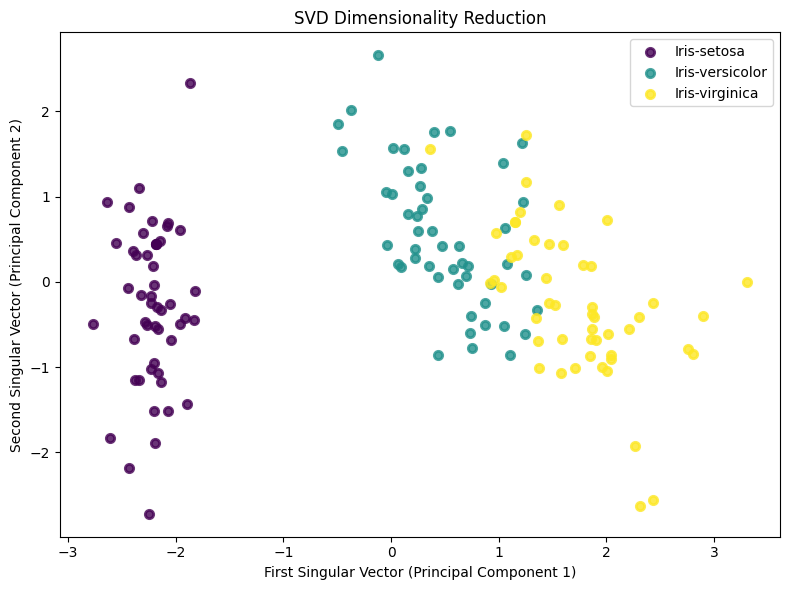

In [ ]:
# Project the data into 2D
# The principal components are the right-singular vectors (rows of V^T or columns of V).
# We project the data onto the first two principal components.
k = 2
V_k = Vt.T[:, :k] # Get the first k columns of V
X_svd = X_std @ V_k


# Visualization
fig, ax = plt.subplots(figsize=(8, 6))

unique_labels = np.unique(y)
colors = plt.cm.get_cmap('viridis', len(unique_labels))
lw = 2

for i, target_name in zip(unique_labels, target_names):
    ax.scatter(X_svd[y == i, 0], X_svd[y == i, 1],
               color=colors(i), alpha=.8, lw=lw, label=target_name)


ax.set_title('SVD Dimensionality Reduction')
ax.set_xlabel('First Singular Vector (Principal Component 1)')
ax.set_ylabel('Second Singular Vector (Principal Component 2)')
ax.legend(loc='best', shadow=False, scatterpoints=1)

plt.tight_layout()
plt.show()